## Install libraries (optional)

In [1]:
#!pip install -q cartopy

## Import required libraries and read the data

In [1]:
import pandas as pd
import geopandas as gpd

df_perceived = pd.read_csv(r'../../datafiles/processed/flood_table.csv')
gdf_perceived = gpd.read_file(r'../../shapefiles/India_District_2023_simple10/district_state_shapefile_2023.shp')

# 1. Reformat Shapefile (Section 3.0 in your R code)
# Rename columns to match your desired output names
gdf_district = gdf_perceived[['GeoName', 'GEOID', 'di_code', 'geometry']].copy()
gdf_district = gdf_district.rename(columns={'GeoName': 'ShapeName', 'GEOID': 'ShapeID'})

# 2. Normalize Names for Merging (The fix for Section 4.0)
# Create a temporary lowercase column in both dataframes to ensure a perfect match
gdf_district['merge_key'] = gdf_district['ShapeName'].str.lower().str.strip()
df_perceived['merge_key'] = df_perceived['GeoName'].str.lower().str.strip()

# 3. Merge Data (Section 4.0 in your R code)
# Using 'how="outer"' replicates the R 'all=TRUE'
shape_merge = gdf_district.merge(df_perceived, on='merge_key', how='outer')

# Clean up: remove the temporary key and the redundant GeoName column from the CSV side
perceived_data = shape_merge.drop(columns=['merge_key', 'GeoName'])[['di_code', 'pred_per']]
perceived_data = perceived_data.dropna()
perceived_data['di_code'] = perceived_data['di_code'].astype(int)
perceived_data = perceived_data.rename(columns={'pred_per': 'perceived'})

perceived_data

,di_code,perceived
0,673,70.506683
1,438,83.337763
2,440,83.815666
3,674,83.034047
4,447,83.034047
...,...,...
728,301,67.879453
729,707,63.439604
730,302,65.093100
731,617,62.033784


In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from shapely.geometry import Polygon, MultiPolygon

# read the district file
dist_fp = r'../../shapefiles/India_District_2023_simple10/India_District_2023.shp'
gdf = gpd.read_file(dist_fp)
gdf = gdf.dropna()
gdf['di_code'] = gdf['di_code'].astype(int)

# add perception data
gdf = gdf.set_index('di_code').join(perceived_data.set_index('di_code'), how='left')

gdf.head()

,fid,state23,st_code,dist23,st_di23,Shape_Leng,Shape_Area,GeoName,GEOID,class,floodindex,geometry,perceived
di_code,,,,,,,,,,,,,
673,1.0,GUJARAT,24,MORBI,"GUJARAT, MORBI",539476.764723,4.791280e+09,"GUJARAT, MORBI",x24673,0,High,"POLYGON ((71.27029 23.15576, 71.27005 23.15116...",70.506683
438,2.0,GUJARAT,24,AHMADABAD,"GUJARAT, AHMADABAD",857254.094647,6.966374e+09,"GUJARAT, AHMADABAD",x24438,-1,NoData,"POLYGON ((71.97206 23.05747, 71.96077 23.04709...",83.337763
440,3.0,GUJARAT,24,ANAND,"GUJARAT, ANAND",393046.690523,3.054307e+09,"GUJARAT, ANAND",x24440,0,High,"POLYGON ((73.21882 22.62125, 73.216 22.62028, ...",83.815666
674,4.0,GUJARAT,24,DEVBHUMI DWARKA,"GUJARAT, DEVBHUMI DWARKA",661732.986530,4.002784e+09,"GUJARAT, DEVBHUMI DWARKA",x24674,0,High,"MULTIPOLYGON (((69.7547 22.41837, 69.75085 22....",83.034047
447,5.0,GUJARAT,24,JAMNAGAR,"GUJARAT, JAMNAGAR",737428.071884,5.694271e+09,"GUJARAT, JAMNAGAR",x24447,2,Medium,"MULTIPOLYGON (((70.49275 22.85182, 70.49379 22...",83.034047


## Convert assessed risk data from classes to numbers

In [4]:
# Define the scale
flood_mapping = {
    'Very High': 100,
    'High': 75,
    'Medium': 50,
    'Low': 25,
    'Very Low': 0,
    'NoData': np.nan
}

# Apply the mapping to a new column
gdf['assessed'] = gdf['floodindex'].map(flood_mapping)
gdf['gap'] = gdf['assessed'] - gdf['perceived']

gdf.head()

,fid,state23,st_code,dist23,st_di23,Shape_Leng,Shape_Area,GeoName,GEOID,class,floodindex,geometry,perceived,assessed,gap
di_code,,,,,,,,,,,,,,,
673,1.0,GUJARAT,24,MORBI,"GUJARAT, MORBI",539476.764723,4.791280e+09,"GUJARAT, MORBI",x24673,0,High,"POLYGON ((71.27029 23.15576, 71.27005 23.15116...",34.887134,75.0,40.112866
438,2.0,GUJARAT,24,AHMADABAD,"GUJARAT, AHMADABAD",857254.094647,6.966374e+09,"GUJARAT, AHMADABAD",x24438,-1,NoData,"POLYGON ((71.97206 23.05747, 71.96077 23.04709...",34.800767,NaN,NaN
440,3.0,GUJARAT,24,ANAND,"GUJARAT, ANAND",393046.690523,3.054307e+09,"GUJARAT, ANAND",x24440,0,High,"POLYGON ((73.21882 22.62125, 73.216 22.62028, ...",37.012866,75.0,37.987134
674,4.0,GUJARAT,24,DEVBHUMI DWARKA,"GUJARAT, DEVBHUMI DWARKA",661732.986530,4.002784e+09,"GUJARAT, DEVBHUMI DWARKA",x24674,0,High,"MULTIPOLYGON (((69.7547 22.41837, 69.75085 22....",28.216682,75.0,46.783318
447,5.0,GUJARAT,24,JAMNAGAR,"GUJARAT, JAMNAGAR",737428.071884,5.694271e+09,"GUJARAT, JAMNAGAR",x24447,2,Medium,"MULTIPOLYGON (((70.49275 22.85182, 70.49379 22...",28.216682,50.0,21.783318


## Aggregated the data to state level

In [5]:
%%time

# 1. Define a helper to handle the mode (takes the first result if there is a tie)
def get_mode(x):
    return x.mode().iloc[0] if not x.mode().empty else None

# 2. Dissolve the districts into states
# We group by 'state' and apply 'get_mode' to the 'floodrisk' column
gdf_state = gdf.dissolve(
    by='state23',
    aggfunc={'assessed': np.mean, 'perceived': np.mean}
)

# 3. Check the result
# 'state' is now the index, and the geometry is the combined state shape
gdf_state.reset_index(inplace=True)
gdf_state.set_crs("EPSG:4326", allow_override=True, inplace=True)

# delete holes
def remove_holes(geometry):
    if geometry.geom_type == 'Polygon':
        return Polygon(geometry.exterior)
    elif geometry.geom_type == 'MultiPolygon':
        # Reconstruct each part of the MultiPolygon without holes
        return MultiPolygon([Polygon(p.exterior) for p in geometry.geoms])
    return geometry
gdf_state.geometry = gdf_state.geometry.apply(remove_holes)

gdf_state['gap'] = gdf_state['assessed'] - gdf_state['perceived']

gdf_state.head()

CPU times: total: 1.61 s
Wall time: 1.66 s


,state23,geometry,assessed,perceived,gap
0,ANDAMAN & NICOBAR,"MULTIPOLYGON (((92.54257 10.88393, 92.54772 10...",25.000000,32.278504,-7.278504
1,ANDHRA PRADESH,"MULTIPOLYGON (((79.31876 13.11333, 79.31857 13...",57.692308,25.442302,32.250005
2,ARUNACHAL PRADESH,"POLYGON ((93.3241 26.96008, 93.29777 26.95634,...",5.000000,22.020939,-17.020939
3,ASSAM,"POLYGON ((92.71138 24.40722, 92.71327 24.40332...",87.121212,28.522665,58.598547
4,BIHAR,"POLYGON ((85.37952 24.55112, 85.39187 24.54648...",68.421053,39.750483,28.670569


## Plot the maps

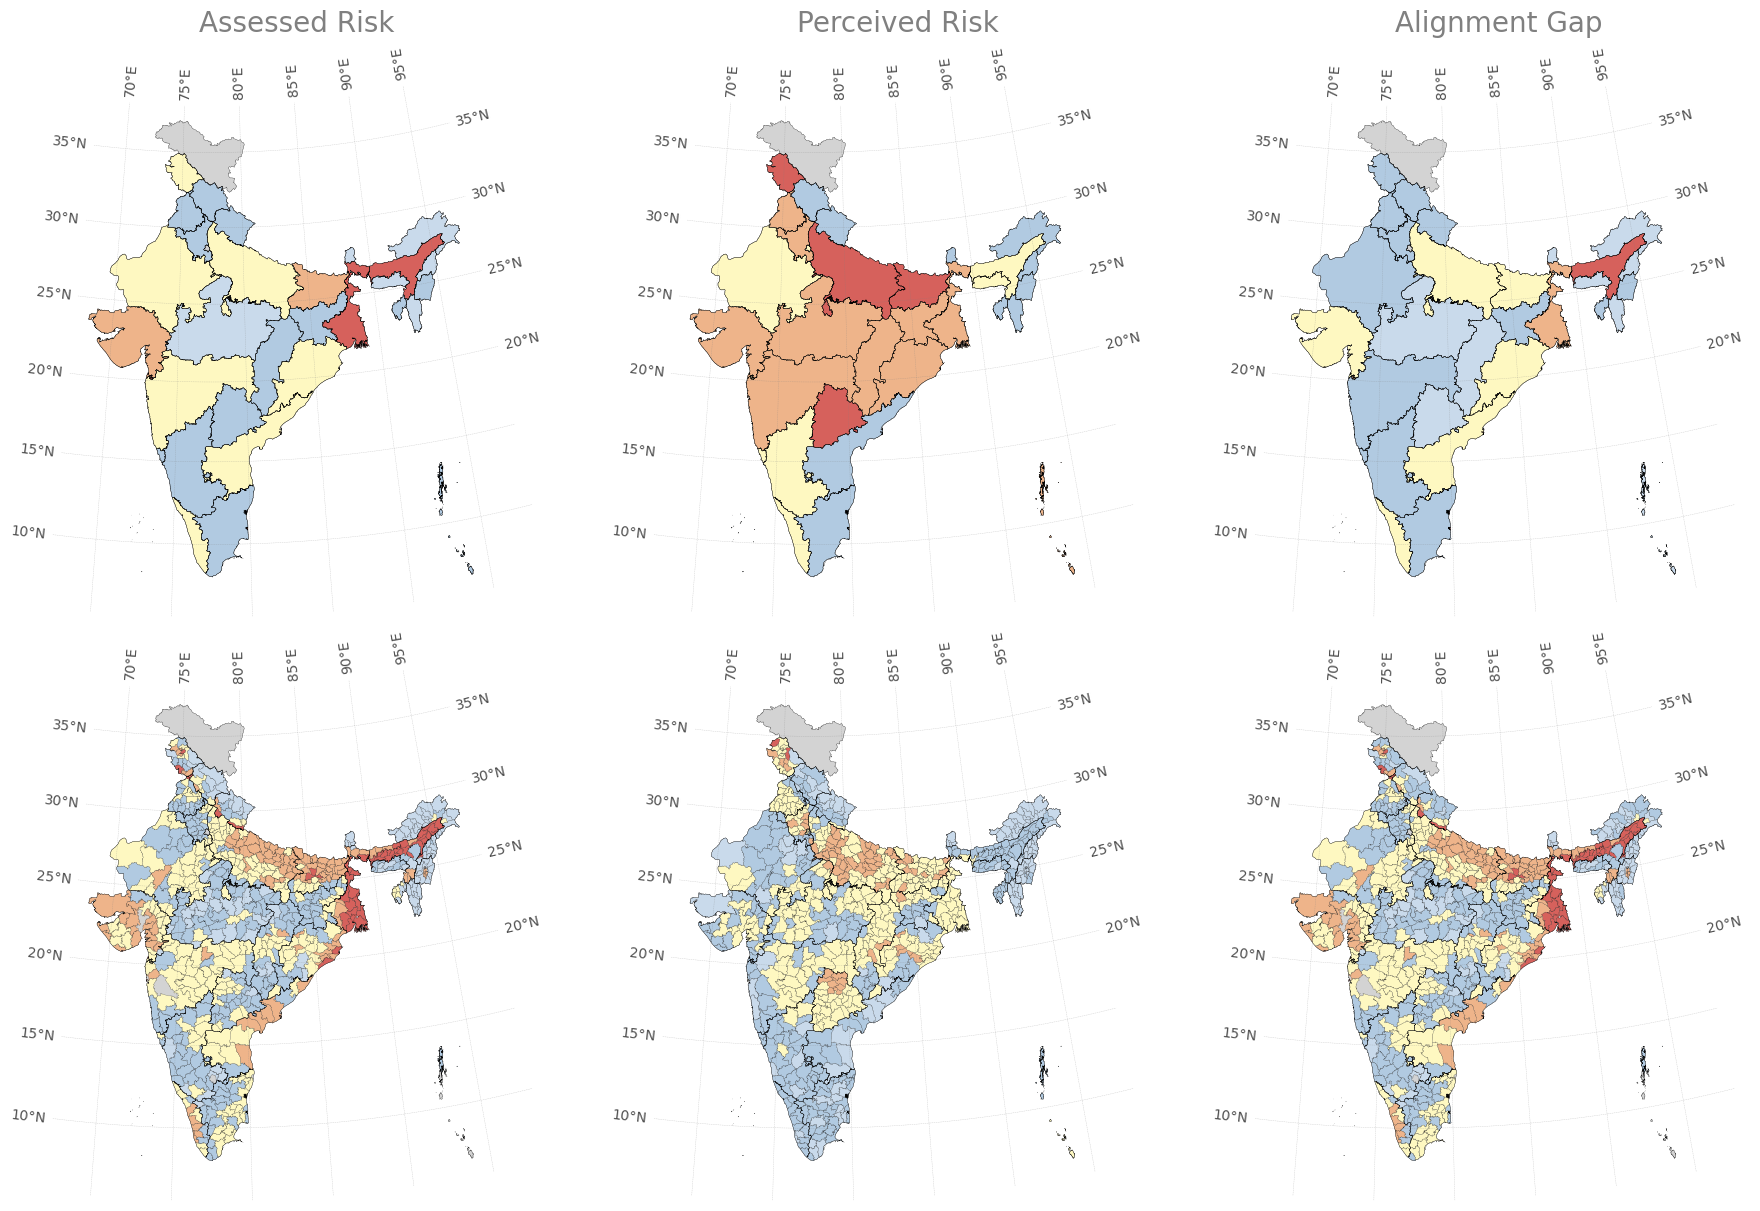

CPU times: total: 4min 37s
Wall time: 4min 48s


In [7]:
%%time

import matplotlib.pyplot as plt
import matplotlib.path as mpath
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, BoundaryNorm

# --- 1. GLOBAL SETTINGS ---
STRAIGHT_LON = 77.5
PROJ = ccrs.LambertConformal(central_longitude=STRAIGHT_LON, central_latitude=23.0)
DATA_CRS = ccrs.PlateCarree()
BOUNDS = gdf.total_bounds
PAD = 1.0

# --- 2. PRE-CALCULATE THE CURVED BOUNDARY ---
n = 100
lons = np.r_[np.linspace(BOUNDS[0]-PAD, BOUNDS[2]+PAD, n), np.full(n, BOUNDS[2]+PAD),
             np.linspace(BOUNDS[2]+PAD, BOUNDS[0]-PAD, n), np.full(n, BOUNDS[0]-PAD)]
lats = np.r_[np.full(n, BOUNDS[1]-PAD), np.linspace(BOUNDS[1]-PAD, BOUNDS[3]+PAD, n),
             np.full(n, BOUNDS[3]+PAD), np.linspace(BOUNDS[3]+PAD, BOUNDS[1]-PAD, n)]
AOI_PATH = mpath.Path(np.column_stack([lons, lats]))

# --- 3. THE UPDATED FORMATTING FUNCTION ---
def format_india_map(ax, title):
    """Applies projection, hides spines, adds graticules, and disables right labels."""
    # Clip the map to our custom area
    ax.set_boundary(AOI_PATH, transform=DATA_CRS)
    ax.set_extent([BOUNDS[0]-PAD, BOUNDS[2]+PAD, BOUNDS[1]-PAD, BOUNDS[3]+PAD], crs=DATA_CRS)

    # REMOVE OUTER BOUNDARY: Hide the spines (the map frame)
    ax.spines['geo'].set_visible(False)   # For newer Cartopy

    # GRATICULES: Add and customize labels
    # Force labels to stay outside the map area (fixes the "middle of the map" issue)
    gl = ax.gridlines(
        draw_labels=True, linewidth=0.3, color='gray', alpha=0.4, linestyle='--',
        x_inline=False, y_inline=False
    )

    # TURN OFF RIGHT LABELS (and top labels for a cleaner look)
    gl.top_labels = True      # Enable top
    gl.left_labels = True     # Enable left
    gl.right_labels = False    # Turn off right
    gl.bottom_labels = False   # Turn off bottom (cleans up the middle of the grid)
    gl.padding = 10  # Increases distance between labels and the map data

    # FONT SIZE CHANGES HERE
    gl.xlabel_style = {'size': 10, 'color': '#4F4F4F', 'weight': 'normal'}
    gl.ylabel_style = {'size': 10, 'color': '#4F4F4F', 'weight': 'normal'}

    ax.set_title(title, fontsize=20, pad=10, color='gray')

# --- 4. CREATE THE FIGURE ---
fig, axs = plt.subplots(2, 3, figsize=(18, 12), subplot_kw={'projection': PROJ}, constrained_layout=True)
(ax1, ax2, ax3), (ax4, ax5, ax6) = axs # Unpack for easy access

# Mapping floodindex to the exact colors from the HHI scale
# Using a logical progression from Cool (Low) to Warm (High)
flood_color_map = {
    'Very Low':  '#c9daeb', # Lightest Blue
    'Low':       '#b1cae1', # Light Blue
    'Medium':    '#fef8c1', # Pale Yellow (The transition point)
    'High':      '#eeb48a', # Light Orange
    'Very High': '#d6615c', # Burnt Red/Orange
    'NoData':    '#f1f8fd'  # Near-white/Grey for missing info
}
ordered_colors = [
    '#c9daeb', # Very Low (0)
    '#b1cae1', # Low (25)
    '#fef8c1', # Medium (50)
    '#eeb48a', # High (75)
    '#d6615c'  # Very High (100)
]
custom_cmap = ListedColormap(ordered_colors)

# --- 5. INDIVIDUAL PLOTTING LINES ---
# Variable 1: Plotting your GDF with standard orange
format_india_map(ax1, "Assessed Risk")
gdf_state.plot(ax=ax1, transform=DATA_CRS, facecolor='lightgray', edgecolor='none')
gdf_state.boundary.plot(ax=ax1, transform=DATA_CRS, color='black', linewidth=0.2)
#colors_ax1 = [flood_color_map.get(val, 'white') for val in gdf_state['floodindex']]
gdf_state.plot(ax=ax1, column='assessed', cmap=custom_cmap, vmin=0, vmax=100, transform=DATA_CRS, edgecolor='black', linewidth=0.2)

# Variable 2: You can change the facecolor here
format_india_map(ax2, "Perceived Risk")
gdf_state.plot(ax=ax2, transform=DATA_CRS, facecolor='lightgray', edgecolor='none')
gdf_state.boundary.plot(ax=ax2, transform=DATA_CRS, color='black', linewidth=0.2)
gdf_state.plot(ax=ax2, column='perceived', cmap=custom_cmap, transform=DATA_CRS, edgecolor='black', linewidth=0.2)

# Variable 3: Example of adding a different alpha/transparency
format_india_map(ax3, "Alignment Gap")
gdf_state.plot(ax=ax3, transform=DATA_CRS, facecolor='lightgray', edgecolor='none')
gdf_state.boundary.plot(ax=ax3, transform=DATA_CRS, color='black', linewidth=0.2)
gdf_state.plot(ax=ax3, column='gap', cmap=custom_cmap, transform=DATA_CRS, edgecolor='black', linewidth=0.2)

# Variable 4: Ready for your next variable
format_india_map(ax4, "")
gdf_state.plot(ax=ax4, transform=DATA_CRS, facecolor='lightgray', edgecolor='none')
gdf.plot(ax=ax4, column='assessed', cmap=custom_cmap, vmin=0, vmax=100, transform=DATA_CRS, edgecolor='black', linewidth=0.1)
gdf_state.boundary.plot(ax=ax4, transform=DATA_CRS, color='black', linewidth=0.2)

# Variable 5: Ready for your next variable
format_india_map(ax5, "")
gdf_state.plot(ax=ax5, transform=DATA_CRS, facecolor='lightgray', edgecolor='none')
gdf.plot(ax=ax5, column='perceived', cmap=custom_cmap, transform=DATA_CRS, edgecolor='black', linewidth=0.1)
gdf_state.boundary.plot(ax=ax5, transform=DATA_CRS, color='black', linewidth=0.2)

# Variable 6: Ready for your next variable
format_india_map(ax6, "")
gdf_state.plot(ax=ax6, transform=DATA_CRS, facecolor='lightgray', edgecolor='none')
gdf.plot(ax=ax6, column='gap', cmap=custom_cmap, transform=DATA_CRS, edgecolor='black', linewidth=0.1)
gdf_state.boundary.plot(ax=ax6, transform=DATA_CRS, color='black', linewidth=0.2)

plt.savefig('../../output/India_FloodRisk_ActualPerceived_v4.pdf', dpi=300, bbox_inches='tight')
plt.show()